# Manually Run the action recognition pipeline

This notebook is used to manually run and visualise each step of the action recognition pipeline. This is helpful for testing, debugging, and using as a live demo. Many of the below steps are automated and optimised in the 'scripts' and 'src' python files. 

In [1]:
import sys
from pathlib import Path

project_root = Path("..")
sys.path.append(str(project_root))

In [2]:
import torch

from src.aggregation import MeanPooling, QueryScoringAggregator
from src.prompting import MPVRPrompts, TemplatePrompts
from src.sampling import MotionGuidedSampler, UniformSampler
from src.utils import clip
from src.utils.clip import get_video_embeddings
from src.utils.dataset import VideoDataset
from src.video_classifier import VideoClassifier
from pathlib import Path
import pandas as pd
from src.utils.constants import RESULTS_DIR, PROJECT_ROOT

import torch.nn.functional as functional

c:\Users\kokos\anaconda3\envs\zsar_project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from IPython.display import Video
import cv2
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

video_path = PROJECT_ROOT / "data" / "UCF-101" / "Basketball" / "v_Basketball_g02_c01.avi"


def play_avi_video(video_path):
    cap = cv2.VideoCapture(str(video_path))
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()

    if not frames:
        print(f"Error: Could not read video at {video_path}")
        return

    fig = plt.figure(figsize=(6, 4))
    plt.axis('off')
    im = plt.imshow(frames[0])
    plt.title(f"Video: {video_path.name} ({len(frames)} frames)")

    def animate(i):
        im.set_array(frames[i])
        return [im]

    anim = animation.FuncAnimation(fig, animate, frames=len(frames), interval=40, blit=True)
    plt.close()

    return HTML(anim.to_jshtml())

print(f"Processing video: {video_path.name}")
play_avi_video(video_path)

Processing video: v_Basketball_g02_c01.avi


## Define pipeline and classes

In [4]:
classes = VideoDataset().get_classes()

print(f"Total Class Count: {len(classes)}")
df_classes = pd.DataFrame(classes, columns=["Class Names"])
display(df_classes.head(10))

sampler = MotionGuidedSampler(16)
aggregator = QueryScoringAggregator()
prompter = TemplatePrompts(classes)

video_classifier = VideoClassifier(classes)

pipeline_name = f"{sampler.name}_{aggregator.name}_{prompter.name}"

video_classifier.set_sampler(sampler).set_aggregator(aggregator).set_prompter(prompter)

print(f"Running pipeline: {pipeline_name}")

# Run classification


Total Class Count: 101


,Class Names
0,ApplyEyeMakeup
1,ApplyLipstick
2,Archery
3,BabyCrawling
4,BalanceBeam
5,BandMarching
6,BaseballPitch
7,Basketball
8,BasketballDunk
9,BenchPress


Running pipeline: MGSampler16_QueryScoringAggregator_TemplatePrompts


## Get class representations

In [5]:
class_to_text_embedding = prompter.get_prompt_embeddings_map()

text_embeddings = torch.stack(
    [class_to_text_embedding[cls] for cls in classes]
).to(clip.DEVICE)

# Normalize text embeddings for cosine similarity
text_embeddings = functional.normalize(text_embeddings, p=2, dim=-1)


## Sample frames from the video and get their embeddings

Selected the frame indexes: [1, 6, 10, 13, 17, 20, 24, 28, 31, 35, 38, 41, 43, 46, 48, 50]
Total Frames Sampled: 16
Showing 5 examples:


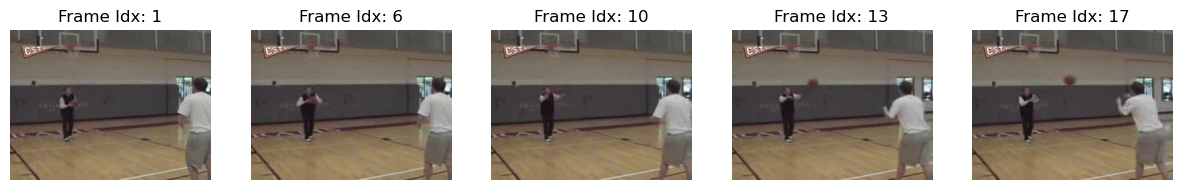

In [10]:
from src.utils.clip import compute_frame_embeddings, extract_selected_frames
import matplotlib.pyplot as plt
from src.utils.clip import extract_selected_frames

selected_indexes = sampler.sample(video_path)

sampled = compute_frame_embeddings(extract_selected_frames(video_path, selected_indexes))

sampled = sampled.to(clip.DEVICE)

print("Selected the frame indexes:", selected_indexes)


# Visualise sampled frames
frame_images = extract_selected_frames(video_path, selected_indexes)

num_to_show = min(5, len(frame_images))
fig, axes = plt.subplots(1, num_to_show, figsize=(15, 3))

print(f"Total Frames Sampled: {len(selected_indexes)}")
print(f"Showing {num_to_show} examples:")

if num_to_show == 1: axes = [axes]
for i, ax in enumerate(axes):
    ax.imshow(frame_images[i])
    ax.set_title(f"Frame Idx: {selected_indexes[i]}")
    ax.axis("off")

plt.show()

## Use aggregation method to produce video representation

In [7]:
video_embedding = aggregator.aggregate(
    sampled, text_embeddings=text_embeddings
)

video_embedding = functional.normalize(
    video_embedding.to(clip.DEVICE), p=2, dim=-1
)

print(f"Text Embeddings (Classes):   {text_embeddings.shape}")
print(f"Frame Embeddings (Sampled):  {sampled.shape}")
print(f"Final Video Representation:  {video_embedding.shape}")


Text Embeddings (Classes):   torch.Size([101, 512])
Frame Embeddings (Sampled):  torch.Size([16, 512])
Final Video Representation:  torch.Size([512])


## Compare video representation to class representations for final prediction

In [11]:
# Calculate cosine similarity to get a tensor of similarities between the video and each class
similarities = video_embedding @ text_embeddings.T

predicted_label = classes[similarities.argmax().item()]

# End of classification

print(f"Predicted class: {predicted_label}")

Predicted class: BasketballDunk


In [9]:
import pandas as pd

df_results = pd.DataFrame({
    "Class": classes,
    "Score": similarities.flatten().detach().cpu().numpy()
})

df_results = df_results.sort_values(by="Score", ascending=False).reset_index(drop=True)
df_results.index += 1

print(df_results.head(10))

                Class     Score
1      BasketballDunk  0.303158
2          Basketball  0.297041
3       JugglingBalls  0.278628
4      SoccerJuggling  0.278199
5         ThrowDiscus  0.273968
6        JavelinThrow  0.273360
7         HammerThrow  0.271337
8            HulaHoop  0.270104
9   TrampolineJumping  0.267491
10           JumpRope  0.265017
